In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import time
import optuna
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('bus_eta_standard_scaled.csv')

print("Data shape:", df.shape)

# Prepare the data
X = df.drop(columns=['timestamp', 'eta_minutes'])  # Features
y = df['eta_minutes']  # Target

# Print feature and target variable information
print("\n=== Feature and Target Information ===")
print(f"Target variable: 'eta_minutes'")
print(f"Number of features: {X.shape[1]}")
print("\nFeature list:")
for i, feature in enumerate(X.columns):
    print(f"{i+1}. {feature}")

print("\nFirst 5 rows of features:")
print(X.head())

print("\nFirst 5 values of target variable:")
print(y.head())

print("\nFeature statistics:")
print(X.describe())

print("\nTarget variable statistics:")
print(y.describe())

# Function to evaluate and visualize model performance
def evaluate_model(model, X_test, y_test, model_name):
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    accuracy = 100 - mape
    
    print(f"--- {model_name} Performance Metrics ---")
    print(f'RMSE: {rmse:.2f}')
    print(f'R² Score: {r2:.4f}')
    print(f"MAPE: {mape:.2f}%")
    print(f"Prediction Accuracy: {accuracy:.2f}%")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # Scatter plot of actual vs predicted
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', linestyle='--')
    axes[0, 0].set_xlabel("Actual ETA")
    axes[0, 0].set_ylabel("Predicted ETA")
    axes[0, 0].set_title(f"{model_name}: Actual vs. Predicted ETA")
    
    # Line plot of first 50 samples
    axes[0, 1].plot(y_test.values[:50], label="Actual", marker='o')
    axes[0, 1].plot(y_pred[:50], label="Predicted", marker='x')
    axes[0, 1].set_xlabel("Sample Index")
    axes[0, 1].set_ylabel("ETA (minutes)")
    axes[0, 1].set_title(f"{model_name}: Actual vs. Predicted ETA (First 50 Samples)")
    axes[0, 1].legend()
    
    # Histogram of errors
    errors = y_pred - y_test
    axes[1, 0].hist(errors, bins=30, edgecolor='black')
    axes[1, 0].set_xlabel("Prediction Error (Predicted - Actual)")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title(f"{model_name}: Histogram of Prediction Errors")
    
    # Percentage error vs actual
    percentage_error = 100 * (y_pred - y_test) / y_test
    axes[1, 1].scatter(y_test, percentage_error, alpha=0.5)
    axes[1, 1].axhline(y=0, color='r', linestyle='--')
    axes[1, 1].set_xlabel("Actual ETA (minutes)")
    axes[1, 1].set_ylabel("Prediction Error (%)")
    axes[1, 1].set_title(f"{model_name}: Prediction Error vs. Actual ETA")
    
    plt.tight_layout()
    plt.show()
    
    return {
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'accuracy': accuracy,
        'predictions': y_pred
    }

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# ============== OPTUNA OPTIMIZATION ==============

# IMPORTANT: We need to define the max_bin parameter BEFORE creating the Dataset
# Set a fixed max_bin value - this can't be tuned with Optuna if we want to reuse the same Dataset
max_bin = 500

# Create LGB datasets AFTER setting max_bin - this is important to avoid the error
lgb_train = lgb.Dataset(X_train, y_train, params={'max_bin': max_bin})
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

def objective(trial):
    """Optuna objective function for LightGBM optimization"""
    
    # Define the hyperparameter search space
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),
        'num_leaves': trial.suggest_int('num_leaves', 20, 3000, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 25),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 1e-8, 1.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'max_bin': max_bin,  # Use the fixed max_bin value
        'feature_pre_filter': False,  # Add this line to fix the error
        'verbose': -1
    }
    
    # Add bagging parameters only if boosting_type is not GOSS
    if param['boosting_type'] != 'goss':
        param['bagging_fraction'] = trial.suggest_float('bagging_fraction', 0.4, 1.0)
        param['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 10)
    
    # Add GOSS-specific parameters if GOSS is selected
    if param['boosting_type'] == 'goss':
        param['top_rate'] = trial.suggest_float('top_rate', 0.1, 0.9)
        param['other_rate'] = trial.suggest_float('other_rate', 0.0, min(0.9, 1.0 - param['top_rate']))
    
    num_boost_round = trial.suggest_int('num_iterations', 100, 2000)
    
    # Train with early stopping
    model = lgb.train(
        param,
        lgb_train,
        num_boost_round=num_boost_round,
        valid_sets=[lgb_eval],
        callbacks=[
            lgb.callback.early_stopping(stopping_rounds=100, verbose=False),
            lgb.callback.log_evaluation(period=0)  # Reduced logging to avoid cluttering output
        ]
    )
    
    # Return the validation error
    return model.best_score['valid_0']['rmse']

# Create and run the study
print("\n=== Starting Optuna Hyperparameter Optimization ===")
start_time = time.time()

# Create a study and optimize
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200)  # Adjust number of trials as needed based on computational resources

optimization_time = time.time() - start_time
print(f"Optimization completed in {optimization_time:.2f} seconds")

# Get the best parameters
best_params = study.best_params
best_params['objective'] = 'regression'
best_params['metric'] = 'rmse'
best_params['verbose'] = -1
best_params['max_bin'] = max_bin  # Ensure max_bin is included

# Extract num_iterations
num_boost_round = best_params.pop('num_iterations', 1000)

print("\n=== Best Hyperparameters ===")
for param_name, param_value in best_params.items():
    print(f"{param_name}: {param_value}")

# ============== TRAINING FINAL MODEL ==============

print("\n=== Training Final Optimized Model ===")
start_time = time.time()

# Use the best parameters to train the final model
optimized_model = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=num_boost_round,
    valid_sets=[lgb_eval],
    callbacks=[
        lgb.callback.early_stopping(stopping_rounds=100, verbose=True),
        lgb.callback.log_evaluation(period=100)
    ]
)

final_training_time = time.time() - start_time
print(f"Final model training time: {final_training_time:.2f} seconds")

# Evaluate the final model
final_results = evaluate_model(optimized_model, X_test, y_test, "Optuna Optimized LightGBM Model")

# Feature importance plot
plt.figure(figsize=(14, 10))
lgb.plot_importance(optimized_model, max_num_features=30, figsize=(14, 10))
plt.title('Feature Importance (Optuna Optimized Model)')
plt.tight_layout()
plt.show()

# Print the top 20 most important features
print("\n=== Top 20 Most Important Features ===")
feature_importance = optimized_model.feature_importance(importance_type='gain')
feature_names = optimized_model.feature_name()
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False).head(20)
for i, (feature, importance) in enumerate(zip(importance_df['Feature'], importance_df['Importance'])):
    print(f"{i+1}. {feature}: {importance}")

# Save the optimized model
model_file = 'lightgbm_optuna_optimized_model.txt'
optimized_model.save_model(model_file)
print(f"Optimized model saved as '{model_file}'")

# Also save as joblib for easier loading
joblib_file = 'lightgbm_optuna_optimized_model.joblib'
joblib.dump(optimized_model, joblib_file)
print(f"Optimized model also saved as '{joblib_file}'")

# Print Optuna optimization history (more detailed visualization requires plotly)
print("\n=== Optimization History ===")
trials = study.trials
print(f"Best trial value: {study.best_value}")
print(f"Best trial parameters: {study.best_params}")

# Optuna visualization (uncomment if you have plotly installed)
try:
    import plotly
    print("\nGenerating Optuna visualizations...")
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
    fig = optuna.visualization.plot_param_importances(study)
    fig.show()
except ImportError:
    print("\nPlotly not installed. Skipping Optuna visualizations.")
    print("Install plotly with 'pip install plotly' to enable visualizations.")

# ============== TIME HORIZON PREDICTIONS ==============

print("\n=== Time Horizon Predictions ===")

# Define the time horizons in minutes
time_horizons = [1, 3, 5, 15, 30, 60]  # 1 min, 3 mins, 5 mins, 15 mins, 30 mins, 1 hour

# Function to filter test data for specific time horizons
def get_horizon_data(X_test, y_test, horizon, tolerance=0.5):
    """
    Filter the test data to include samples close to the specified time horizon.
    
    Args:
        X_test: Test features
        y_test: Test target values
        horizon: Target time horizon in minutes
        tolerance: Tolerance range (±) in minutes
        
    Returns:
        X_horizon, y_horizon: Filtered data for the specified horizon
    """
    # Convert to numpy arrays if they're not already
    if isinstance(X_test, pd.DataFrame):
        X_test = X_test.values
    if isinstance(y_test, pd.Series):
        y_test = y_test.values
    
    # Find indices where y_test is within the horizon ± tolerance
    horizon_mask = (y_test >= horizon - tolerance) & (y_test <= horizon + tolerance)
    
    if not horizon_mask.any():
        print(f"No exact data points found for horizon {horizon} minutes (±{tolerance})")
        # If no exact matches, get closest values
        distances = np.abs(y_test - horizon)
        closest_indices = np.argsort(distances)[:max(int(len(y_test) * 0.05), 10)]  # Get top 5% or at least 10 samples
        horizon_mask = np.zeros_like(y_test, dtype=bool)
        horizon_mask[closest_indices] = True
        print(f"Using {sum(horizon_mask)} closest data points instead")
    else:
        print(f"Found {sum(horizon_mask)} data points for horizon {horizon} minutes (±{tolerance})")
    
    X_horizon = X_test[horizon_mask]
    y_horizon = y_test[horizon_mask]
    
    return X_horizon, y_horizon

# Results storage
horizon_results = {}

# Test the model on each time horizon
print("\n=== Time Horizon Performance Comparison ===")
print(f"{'Time Horizon':<15} {'Samples':<10} {'RMSE':<10} {'R²':<10} {'MAPE':<10} {'Accuracy':<10}")
print("-" * 65)

for horizon in time_horizons:
    # Get data for this horizon
    X_horizon, y_horizon = get_horizon_data(X_test, y_test, horizon)
    
    if len(X_horizon) < 5:  # Skip if too few samples
        print(f"{horizon} min: Insufficient data")
        continue
    
    # Make predictions
    y_pred = optimized_model.predict(X_horizon)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_horizon, y_pred))
    r2 = r2_score(y_horizon, y_pred)
    
    # Avoid division by zero in MAPE calculation
    valid_indices = y_horizon != 0
    if np.any(valid_indices):
        mape = np.mean(np.abs((y_horizon[valid_indices] - y_pred[valid_indices]) / y_horizon[valid_indices])) * 100
    else:
        mape = np.nan
    
    accuracy = 100 - mape if not np.isnan(mape) else np.nan
    
    horizon_results[horizon] = {
        'samples': len(X_horizon),
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'accuracy': accuracy
    }
    
    print(f"{horizon} min:{'':<9} {len(X_horizon):<10d} {rmse:<10.2f} {r2:<10.4f} {mape:<10.2f}% {accuracy:<10.2f}%")

# Visualization of accuracy across time horizons
plt.figure(figsize=(12, 6))
horizons = list(horizon_results.keys())
accuracies = [horizon_results[h]['accuracy'] for h in horizons]
rmse_values = [horizon_results[h]['rmse'] for h in horizons]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Time Horizon (minutes)')
ax1.set_ylabel('Accuracy (%)', color=color1)
ax1.plot(horizons, accuracies, marker='o', color=color1, linestyle='-', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('RMSE', color=color2)
ax2.plot(horizons, rmse_values, marker='s', color=color2, linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Model Performance Across Different Time Horizons')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# ============== MAKING PREDICTIONS FOR SPECIFIC TIME WINDOWS ==============

print("\n=== Making Predictions for Specific Future Time Windows ===")

# Function to create a dataset for a specific prediction window
def create_prediction_window_dataset(X_test, y_test, window_start, window_end):
    """
    Create a dataset for predictions within a specific time window.
    
    Args:
        X_test: Test features
        y_test: Test target values
        window_start: Start time of the window (in minutes)
        window_end: End time of the window (in minutes)
        
    Returns:
        X_window, y_window: Data for the specified window
    """
    window_mask = (y_test >= window_start) & (y_test <= window_end)
    
    if not window_mask.any():
        print(f"No data points found for window {window_start}-{window_end} minutes")
        # If no exact matches, get closest values
        distances = np.minimum(np.abs(y_test - window_start), np.abs(y_test - window_end))
        closest_indices = np.argsort(distances)[:max(int(len(y_test) * 0.05), 10)]
        window_mask = np.zeros_like(y_test, dtype=bool)
        window_mask[closest_indices] = True
        print(f"Using {sum(window_mask)} closest data points instead")
    else:
        print(f"Found {sum(window_mask)} data points for window {window_start}-{window_end} minutes")
    
    X_window = X_test[window_mask]
    y_window = y_test[window_mask]
    
    return X_window, y_window

# Define time windows (in minutes)
time_windows = [
    (0, 2),     # 0-2 minutes
    (2, 5),     # 2-5 minutes
    (5, 15),    # 5-15 minutes
    (15, 30),   # 15-30 minutes
    (30, 60),   # 30-60 minutes
    (60, 120)   # 1-2 hours
]

# Results storage for time windows
window_results = {}

# Test the model on each time window
print("\n=== Time Window Performance Comparison ===")
print(f"{'Time Window':<15} {'Samples':<10} {'RMSE':<10} {'R²':<10} {'MAPE':<10} {'Accuracy':<10}")
print("-" * 65)

for window_start, window_end in time_windows:
    # Get data for this window
    X_window, y_window = create_prediction_window_dataset(X_test.values, y_test.values, window_start, window_end)
    
    if len(X_window) < 5:  # Skip if too few samples
        print(f"{window_start}-{window_end} min: Insufficient data")
        continue
    
    # Make predictions
    y_pred = optimized_model.predict(X_window)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_window, y_pred))
    r2 = r2_score(y_window, y_pred)
    
    # Avoid division by zero in MAPE calculation
    valid_indices = y_window != 0
    if np.any(valid_indices):
        mape = np.mean(np.abs((y_window[valid_indices] - y_pred[valid_indices]) / y_window[valid_indices])) * 100
    else:
        mape = np.nan
        
    accuracy = 100 - mape if not np.isnan(mape) else np.nan
    
    window_name = f"{window_start}-{window_end} min"
    window_results[window_name] = {
        'samples': len(X_window),
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'accuracy': accuracy
    }
    
    print(f"{window_name:<15} {len(X_window):<10d} {rmse:<10.2f} {r2:<10.4f} {mape:<10.2f}% {accuracy:<10.2f}%")

# Visualization of accuracy across time windows
plt.figure(figsize=(12, 6))
window_names = list(window_results.keys())
accuracies = [window_results[w]['accuracy'] for w in window_names]
rmse_values = [window_results[w]['rmse'] for w in window_names]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Time Window (minutes)')
ax1.set_ylabel('Accuracy (%)', color=color1)
ax1.plot(window_names, accuracies, marker='o', color=color1, linestyle='-', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(window_names, rotation=45)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('RMSE', color=color2)
ax2.plot(window_names, rmse_values, marker='s', color=color2, linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Model Performance Across Different Time Windows')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# ============== MODEL LOADING AND DIRECT PREDICTION EXAMPLE ==============

print("\n=== Model Loading and Direct Prediction Example ===")

# Load the model from file
loaded_model = lgb.Booster(model_file=model_file)

# Example: Predict ETA for a few samples
sample_data = X_test.iloc[:5]

# Make predictions
predictions = loaded_model.predict(sample_data)

print("Sample predictions:")
for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: {pred:.2f} minutes")

print("\nActual values:")
for i, actual in enumerate(y_test.iloc[:5]):
    print(f"Sample {i+1}: {actual:.2f} minutes")

# ============== SAVE RESULTS TO CSV ==============

# Save time horizon results
horizon_df = pd.DataFrame.from_dict(horizon_results, orient='index')
horizon_df.index.name = 'horizon_minutes'
horizon_df.to_csv('time_horizon_results.csv')
print("\nTime horizon results saved to 'time_horizon_results.csv'")

# Save time window results
window_df = pd.DataFrame.from_dict(window_results, orient='index')
window_df.index.name = 'time_window'
window_df.to_csv('time_window_results.csv')
print("Time window results saved to 'time_window_results.csv'")

print("\n=== Optimization Complete ===")

c:\Users\cheng\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-03-18 17:12:24,816] A new study created in memory with name: no-name-feda734d-6832-4b52-8585-33b8d6d2366b


Data shape: (100000, 14)

=== Feature and Target Information ===
Target variable: 'eta_minutes'
Number of features: 12

Feature list:
1. stop_sequence
2. current_stop_name
3. next_stop_name
4. day_of_week
5. is_holiday
6. is_peak_hour
7. weather_condition
8. passenger_count
9. current_speed
10. distance_to_next_stop
11. current_lat
12. current_lon

First 5 rows of features:
   stop_sequence  current_stop_name  next_stop_name  day_of_week  is_holiday  \
0              1                  4               1            0       False   
1              2                  1               2            0       False   
2              3                  2               0            0       False   
3              4                  0               3            0       False   
4              5                  3               4            0       False   

   is_peak_hour  weather_condition  passenger_count  current_speed  \
0         False                  0         0.152207      -0.825070   
1 

[I 2025-03-18 17:12:25,374] Trial 0 finished with value: 0.23503924236601975 and parameters: {'boosting_type': 'goss', 'num_leaves': 337, 'learning_rate': 0.11370320355556969, 'feature_fraction': 0.5804368807591799, 'min_child_samples': 27, 'max_depth': 15, 'lambda_l1': 0.16756848396027568, 'lambda_l2': 0.01828948236489097, 'min_gain_to_split': 0.4202789864372041, 'min_data_in_leaf': 7, 'top_rate': 0.3331941276075989, 'other_rate': 0.1753458459789637, 'num_iterations': 656}. Best is trial 0 with value: 0.23503924236601975.
[I 2025-03-18 17:12:30,818] Trial 1 finished with value: 0.23434945343914754 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 433, 'learning_rate': 0.01899882506758646, 'feature_fraction': 0.9136036927234287, 'min_child_samples': 61, 'max_depth': 24, 'lambda_l1': 2.5941377123177237e-08, 'lambda_l2': 2.881985405331538e-05, 'min_gain_to_split': 1.260142816936808e-05, 'min_data_in_leaf': 29, 'bagging_fraction': 0.8268993860096823, 'bagging_freq': 10, 'num_iterati

KeyboardInterrupt: 

       stop_sequence  current_stop_name  next_stop_name  day_of_week  \
83857              2                  1               2            1   
3282               1                  4               1            5   
19972              5                  3               4            4   
87734              2                  1               2            3   
88224              4                  0               3            6   
51121              5                  3               4            5   
87301              2                  1               2            0   
69475              2                  1               2            1   
69189              1                  4               1            6   
81281              1                  4               1            0   
19597              4                  0               3            2   
88757              2                  1               2            2   
98513              2                  1               2         

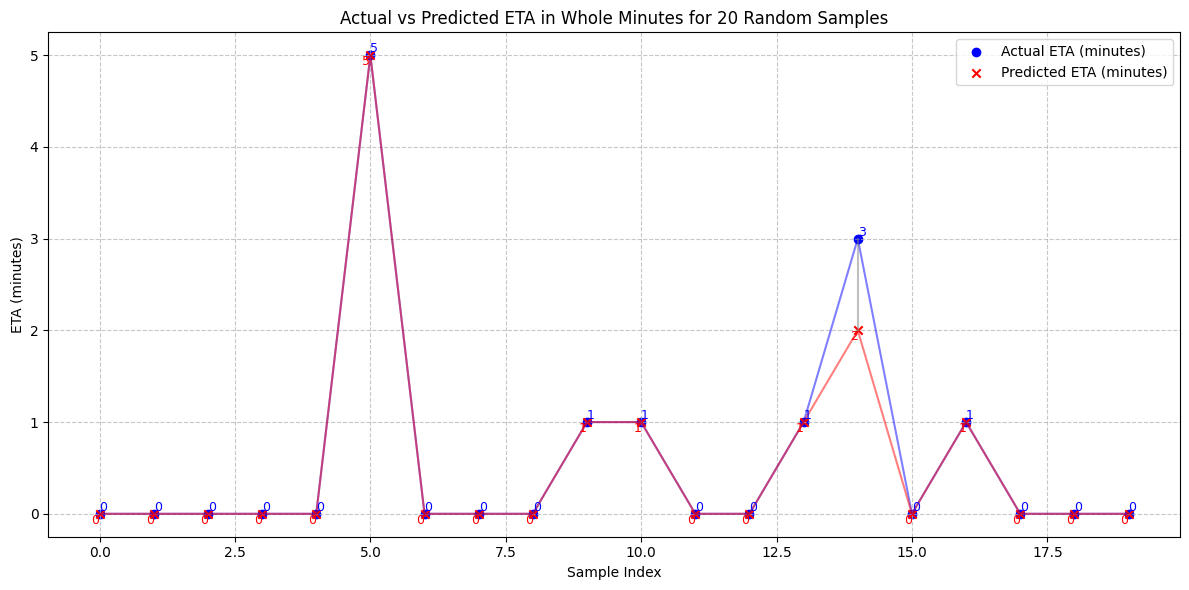


Accuracy Metrics for Whole Minutes:
Exact minute match: 95.00%
Within ±1 minute: 100.00%
Within ±3 minutes: 100.00%
Within ±5 minutes: 100.00%
Mean absolute error: 0.05 minutes


In [7]:
import lightgbm as lgb
import numpy as np
# Load the saved optimized model
loaded_model = lgb.Booster(model_file='lightgbm_optimized_model.txt')

# Get 20 samples from the test data
sample_indices = np.random.choice(len(X_test), size=20, replace=False)
X_sample = X_test.iloc[sample_indices]
y_sample = y_test.iloc[sample_indices]

# Make predictions using the loaded model
y_pred_sample = loaded_model.predict(X_sample)
print(X_sample)

# Since we need to inverse transform the predictions to get actual minutes
# We need to load the scaler used for the target variable or estimate parameters
import joblib

try:
    # Try to load the saved scaler
    y_scaler = joblib.load('eta_standard_scaler.joblib')
    
    # Reshape predictions and actual values for inverse transform
    y_pred_unscaled = y_scaler.inverse_transform(y_pred_sample.reshape(-1, 1)).flatten()
    y_sample_unscaled = y_scaler.inverse_transform(y_sample.values.reshape(-1, 1)).flatten()
    
except (FileNotFoundError, ValueError):
    # If scaler not available, we can estimate the scaling parameters from the data
    print("Scaler not found. Using approximation based on the dataset statistics.")
    
    # Attempt to load original unscaled data
    try:
        original_unscaled_df = pd.read_csv('bus_eta.csv')
        eta_mean = original_unscaled_df['eta_minutes'].mean()
        eta_std = original_unscaled_df['eta_minutes'].std()
    except FileNotFoundError:
        # Estimate mean and std based on available information
        print("Using estimated scaling parameters. Replace with actual values if known.")
        eta_mean = 0  # Assuming StandardScaler was applied (mean becomes 0)
        eta_std = 1   # Assuming StandardScaler was applied (std becomes 1)
    
    # Inverse transform function
    y_pred_unscaled = y_pred_sample * eta_std + eta_mean
    y_sample_unscaled = y_sample.values * eta_std + eta_mean

# Round to nearest whole minute
y_pred_minutes = np.round(y_pred_unscaled).astype(int)
y_actual_minutes = np.round(y_sample_unscaled).astype(int)

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Actual_ETA_Minutes': y_actual_minutes,
    'Predicted_ETA_Minutes': y_pred_minutes,
    'Difference_Minutes': y_pred_minutes - y_actual_minutes
})

# Display the results
print("Prediction Results for 20 Random Samples (in whole minutes):")
print(results_df)

# Visualize the results with whole minutes
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_actual_minutes)), y_actual_minutes, color='blue', marker='o', label='Actual ETA (minutes)')
plt.scatter(range(len(y_pred_minutes)), y_pred_minutes, color='red', marker='x', label='Predicted ETA (minutes)')
plt.plot(range(len(y_actual_minutes)), y_actual_minutes, color='blue', alpha=0.5)
plt.plot(range(len(y_pred_minutes)), y_pred_minutes, color='red', alpha=0.5)

plt.title('Actual vs Predicted ETA in Whole Minutes for 20 Random Samples')
plt.xlabel('Sample Index')
plt.ylabel('ETA (minutes)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Add text labels showing the exact minute values
for i, (actual, pred) in enumerate(zip(y_actual_minutes, y_pred_minutes)):
    plt.text(i, actual, f"{actual}", fontsize=9, ha='left', va='bottom', color='blue')
    plt.text(i, pred, f"{pred}", fontsize=9, ha='right', va='top', color='red')

# Add error bars
for i in range(len(y_actual_minutes)):
    plt.plot([i, i], [y_actual_minutes[i], y_pred_minutes[i]], color='gray', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

# Calculate accuracy metrics
exact_match = np.sum(y_pred_minutes == y_actual_minutes) / len(y_actual_minutes) * 100
within_1_min = np.sum(np.abs(y_pred_minutes - y_actual_minutes) <= 1) / len(y_actual_minutes) * 100
within_3_min = np.sum(np.abs(y_pred_minutes - y_actual_minutes) <= 3) / len(y_actual_minutes) * 100
within_5_min = np.sum(np.abs(y_pred_minutes - y_actual_minutes) <= 5) / len(y_actual_minutes) * 100

print("\nAccuracy Metrics for Whole Minutes:")
print(f"Exact minute match: {exact_match:.2f}%")
print(f"Within ±1 minute: {within_1_min:.2f}%")
print(f"Within ±3 minutes: {within_3_min:.2f}%")
print(f"Within ±5 minutes: {within_5_min:.2f}%")
print(f"Mean absolute error: {np.mean(np.abs(y_pred_minutes - y_actual_minutes)):.2f} minutes")